# Conservation score & sgrna on-target efficiency 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pyranges as pr
import re
import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from Bio import SeqIO
from scipy.stats import ks_2samp
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import ttest_ind
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

from matplotlib import font_manager
import matplotlib as mpl

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'
import warnings
warnings.filterwarnings("ignore")

In [2]:
id_prefix_list = [
	"MYC_GFP_"
]

In [3]:
# remove negative controls that can be mapped to the genome (with bowtie)
mapped_ctrl_path = "/media/scratch/fy2306/projects/base_editing/data/bowtie/all/all_sgrna_seqs.bowtie_hg38.mismatch1.processed.tsv"
mapped_ctrl_df = pd.read_csv(mapped_ctrl_path, sep="\t")
mapped_ctrl_df = mapped_ctrl_df[
    mapped_ctrl_df['id'].str.startswith(('Random', 'Non-targeting-controls', 'AAVS1'))
    & ~(mapped_ctrl_df['id'].str.startswith('AAVS1') & (mapped_ctrl_df['Alignments_NM0'] == 1) & (mapped_ctrl_df['Alignments_NM1'] == 0))
]
mapped_ctrl_list = mapped_ctrl_df["id"].tolist()
print(len(mapped_ctrl_list))
all_ctrl = [
    record.id for record in SeqIO.parse("/media/scratch/fy2306/projects/base_editing/data/bowtie/negative_controls/input/negative_controls.fa", "fasta")
    ]
clean_ctrl_list = list(set(all_ctrl)-set(mapped_ctrl_list))
print(len(clean_ctrl_list))
print(len(all_ctrl))

91
474
565


In [4]:
# randomly group nc sgrnas
def group_and_aggregate(df, group_size, random_state=None):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    num_groups = len(df_shuffled) // group_size
    df_trimmed = df_shuffled.iloc[:num_groups * group_size]
    
    grouped = np.array_split(df_trimmed, num_groups)
    
    aggregated = []
    for group in grouped:
        sgrna_concat = ','.join(group['sgrna'].astype(str))
        avg_lfc = group['per time unit LFC'].mean()
        aggregated.append({
            'sgrna': sgrna_concat,
            'per time unit LFC': avg_lfc
        })
    
    return pd.DataFrame(aggregated)

In [5]:
def conservation_on_target(
	gene, myc_var, cons_col,
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	cons_subset,
	merge_method_replicate,
	conservation_method, 
	conservation_threshold,
	pred_method,
	sgRNA_seq_col,
	score_col,
	window_side_size,
	per_time_unit=True,
	title=None,
	score_smoothing=True):

	score_path = f"/media/scratch/fy2306/projects/base_editing/data/conservation/chr8_myc.{conservation_method}way.wigFix"

	# preprocess
	df_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{test_name}/{merge_method_nucleotide}/myc_repeats/{win_size}/MYC_U1.gene_summary.txt"
	df = pd.read_csv(df_path, sep="\t")
	pattern = f"^({'|'.join(map(re.escape, id_prefix_list))})([0-9]*\.?[0-9]+)"
	df = df[df['id'].str.match(pattern)]
	edited_pos_chr_col = "indel_base_pos_chr"	# nucleotide pos
	df[edited_pos_chr_col] = df['id'].str.extract(pattern)[1].astype(int)	# 1-based

	# merge
	treatment_lfc_columns = [f"{treatment}_vs_{baseline}|neg|lfc" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_columns, day_numbers):
			df[col] = df[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df["neg|lfc"] = df[treatment_lfc_columns].mean(axis=1)

	# add repeats
	rmsk_path = "/media/dna/fy2306/genomes/hg38/RepeatMasker/rmsk.txt"
	rmsk_colnames = ["bin", "swScore", "milliDiv", "milliDel", "milliIns", "genoName", "genoStart", "genoEnd", "genoLeft", "strand", "repName", "repClass", "repFamily", "repStart", "repEnd", "repLeft", "id"]
	rmsk = pd.read_csv(rmsk_path, sep="\t", header=None, names=rmsk_colnames)
	rmsk = rmsk[rmsk['genoName'] == "chr8"]
	# rmsk: 0-based
	rmsk_ranges = pr.PyRanges(rmsk.rename(columns={
	'genoName': 'Chromosome',
	'genoStart': 'Start',
	'genoEnd': 'End'
	}))

	# base_pos: 1-based
	df['Start'] = df[edited_pos_chr_col] - 1
	df['End'] = df['Start'] + 1
	df['Chromosome'] = 'chr8'

	df["orig_index"] = df.index
	df_ranges = pr.PyRanges(df[['Chromosome', 'Start', 'End', 'orig_index']])

	overlap = df_ranges.intersect(rmsk_ranges, how="containment")	# in pyranges: “containment” reports intervals where the overlapping is contained within it, gives you the intervals in self be completely within the intervals in other
	overlap_indices = overlap.df['orig_index'].unique()

	df["indel_repeats_nt"] = False
	df.loc[overlap_indices, "indel_repeats_nt"] = True

	df = df[["id", edited_pos_chr_col, "neg|lfc", "indel_repeats_nt"]]

	# process conservation
	conservation_scores = pd.read_csv(score_path, sep="\t", header=None, names=['chrom', edited_pos_chr_col, 'score'])
	# position: 1-based
	if score_smoothing:
		# rolling
		conservation_scores = conservation_scores.sort_values(by=edited_pos_chr_col).reset_index(drop=True)

		half_win = (int(win_size) // 2)

		smoothed_scores = []

		positions = conservation_scores[edited_pos_chr_col].values
		scores = conservation_scores['score'].values

		for i, pos in enumerate(positions):
			start = pos - half_win	# inclusive
			end = pos + half_win	# inclusive
			
			mask = (positions >= start) & (positions <= end)
			window_scores = scores[mask]
			
			smoothed_scores.append(window_scores.mean() if len(window_scores) > 0 else float('nan'))

		conservation_scores['score'] = smoothed_scores

	df = pd.merge(df, conservation_scores, on=edited_pos_chr_col, how="left")

	# load in lib
	lib_path = f"/media/scratch/fy2306/projects/base_editing/data/grna_type/MYC-lib-for-mageck.type.{myc_var}.organized.txt"
	df_lib = pd.read_csv(lib_path, sep="\t", usecols=[edited_pos_chr_col, "grna_target_seq_rc", "grna_target_seq_rc_strand", cons_col, "indel_repeats"])
	df_lib = df_lib.drop_duplicates(subset=edited_pos_chr_col)
	df = pd.merge(df, df_lib, on=edited_pos_chr_col, how='left')
	df = df[df["indel_repeats_nt"] == False]
	print(df[edited_pos_chr_col].duplicated().sum())
	# add promoter annotation
	df.loc[
		(df[edited_pos_chr_col] >= (127736084-1000)) & (df[cons_col] == 'upstream_flanking'),
		cons_col
		] = 'promoter'

	if cons_subset != "all":
		df = df[df[cons_col].isin(cons_subset)]
	if isinstance(conservation_threshold, float):
		conservation_threshold = conservation_threshold
	elif conservation_threshold == "mean":
		# mean of selected regions
		conservation_threshold = df['score'].mean()
	elif conservation_threshold == "median":
		# median of selected regions
		conservation_threshold = df['score'].median()

	bins = [float('-inf'), conservation_threshold, float('inf')]
	# labels = [f'(-∞, {conservation_threshold:.2f})', f'[{conservation_threshold:.2f}, ∞)']
	labels = ["Other", "Conserved"]

	df['score_bin'] = pd.cut(df['score'], bins=bins, labels=labels, right=False)

	# process the negative controls
	df_nc = None
	for treatment in treatments:
		df_nc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{nc_test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_nc_rep = pd.read_csv(df_nc_path, sep="\t", usecols=["sgrna", "Gene", "LFC"])
		df_nc_rep = df_nc_rep[df_nc_rep["Gene"].isin(["AAVS1", "NT", "Random"])]
		df_nc_rep = df_nc_rep.drop('Gene', axis=1)
		df_nc_rep = df_nc_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_nc is None:
			df_nc = df_nc_rep
		else:
			# Merge on 'sgrna'
			df_nc = pd.merge(df_nc, df_nc_rep, on="sgrna", how="inner")
	print(len(df_nc))

	treatment_lfc_nc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_nc_columns, day_numbers):
			df_nc[col] = df_nc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_nc["per time unit LFC"] = df_nc[treatment_lfc_nc_columns].mean(axis=1)

	# remove mismatches
	df_nc = df_nc[~(df_nc["sgrna"].isin(mapped_ctrl_list))]
	df_nc = df_nc[['sgrna', 'per time unit LFC']]

	# random group of df_nc
	n_repeats = 1000
	all_results = []

	for seed in range(n_repeats):
		df_nc_result = group_and_aggregate(df_nc, group_size=2*int(win_size), random_state=seed)
		all_results.append(df_nc_result)

	df_nc_combined = pd.concat(all_results, ignore_index=True)
	nc_combined_median_value = df_nc_combined["per time unit LFC"].median()
	print(nc_combined_median_value)

	df["neg|lfc"] = df["neg|lfc"] - nc_combined_median_value

	# from on_target_LFC
	if pred_method == "CRISPRon":	# NGG PAM, not exon only
		pred_path = f"/media/scratch/fy2306/projects/base_editing/data/sgRNA_on_target/{pred_method}_MYC.csv"
		df_pred = pd.read_csv(pred_path, sep=",", usecols=[sgRNA_seq_col, score_col], comment="#")
		df_pred[sgRNA_seq_col] = df_pred[sgRNA_seq_col].str[:-3]	# remove PAM
	df_pred[score_col] = df_pred[score_col].astype(float)
	df_pred = pd.merge(df_pred, df_lib, left_on=sgRNA_seq_col, right_on="grna_target_seq_rc", how="inner")
	df_pred = df_pred[df_pred["indel_repeats"] == False]	# sgRNAs are not indel repeats

	# logic from mageck_duplicate_sgRNA
	df_pred = df_pred.sort_values(by=edited_pos_chr_col).reset_index(drop=True)
	# edited_pos_chr_col_cut: from base pos to between-base pos
	edited_pos_chr_col_cut = edited_pos_chr_col + "_cutting_site"
	df_pred[edited_pos_chr_col_cut] = np.where(
		df_pred['grna_target_seq_rc_strand'] == '-',
		df_pred[edited_pos_chr_col] + 0.5,
		df_pred[edited_pos_chr_col] - 0.5
	)

	def avg_eff(row):
		lower = row[edited_pos_chr_col] - window_side_size
		upper = row[edited_pos_chr_col] + window_side_size
		subset = df_pred[
			(df_pred[edited_pos_chr_col_cut] > lower) &
			(df_pred[edited_pos_chr_col_cut] < upper)
		]	# all sgRNAs that can edit this nucleotide
		if len(subset) == 0:
			return np.nan
		return subset[score_col].mean()

	df['average eff'] = df.apply(avg_eff, axis=1)
	df = df.dropna(subset=['average eff'])

	# corr
	r_p, p_p = pearsonr(df["score"], df['average eff'])
	r_s, p_s = spearmanr(df["score"], df['average eff'])

	fig, ax = plt.subplots(figsize=(4, 4))

	hb = ax.hexbin(
		x=df['score'],
		y=df['average eff'],
		gridsize=50,      
		cmap="flare",     
		mincnt=1,
		vmin = 1,
		vmax = 25           
	)

	cax = ax.inset_axes([0.05, 0.15, 0.25, 0.03])

	cb = plt.colorbar(hb, cax=cax, orientation='horizontal')
	cb.set_label("bp count", fontsize=10)
	cb.ax.tick_params(labelsize=10)

	sns.despine(ax=ax, top=True, right=True)
	ax.set_xlim(df["score"].min() - 0.02, df["score"].max() + 0.02)
	ax.set_ylim(df['average eff'].min() - 1, df['average eff'].max() + 1)
	ax.set_xlabel(f"{conservation_method}", fontsize=13)
	ax.set_ylabel("average sgRNA on-target score", fontsize=13)
	ax.set_title(f"{pred_method} {title}", fontsize=13)
	ax.tick_params(labelsize=12)

	ax.text(
		0.98, 0.95,
		f"Pearson r = {r_p:.2f}\n(p = {p_p:.2e})",
		transform=ax.transAxes,
		fontsize=12,
		verticalalignment='top',
		horizontalalignment='right'
	)

	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)

	plt.tight_layout()
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/conservation/conservation_on_target_eff.scatter.{conservation_method}.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

	# original correlation
	df_clean = df.rename(columns={'neg|lfc': 'neg_lfc', 'average eff': 'average_eff'})
	print(f"Number of base pairs covered: {len(df_clean)}")
	r, p = pearsonr(df_clean['score'], df_clean['neg_lfc'])
	# r, p = spearmanr(merged_df["LFC_d8"], merged_df["LFC_d20"])
	print(f"Pearson r: {r:.3f}, p-value: {p:.3e}")

	r, p = pearsonr(df_clean['score'], df_clean['average_eff'])
	# r, p = spearmanr(merged_df["LFC_d8"], merged_df["LFC_d20"])
	print(f"Score and sgRNA average eff: Pearson r: {r:.3f}, p-value: {p:.3e}")

	r, p = pearsonr(df_clean['neg_lfc'], df_clean['average_eff'])
	# r, p = spearmanr(merged_df["LFC_d8"], merged_df["LFC_d20"])
	print(f"neg_lfc and sgRNA average eff: Pearson r: {r:.3f}, p-value: {p:.3e}")

	# partial correlation
	pcorr = pg.partial_corr(data=df_clean, x='score', y='neg_lfc', covar='average_eff', method='pearson')
	print(f"Partial correlation between neg|lfc and conservation score (pcorr): {pcorr['r'].values[0]} (p-value: {pcorr['p-val'].values[0]})")

	X = sm.add_constant(df_clean[['average_eff']])

	neg_lfc_resid = sm.OLS(df_clean['neg_lfc'], X).fit().resid
	score_resid = sm.OLS(df_clean['score'], X).fit().resid

	r_partial = stats.pearsonr(neg_lfc_resid, score_resid).statistic

	# Correct p-value for partial correlation
	n = len(df_clean)
	k = 1  # number of controlled variables
	dfree = n - k - 2

	t_stat = r_partial * np.sqrt(dfree / (1 - r_partial**2))
	p_partial = 2 * stats.t.sf(abs(t_stat), df=dfree)

	print(
		f"Partial correlation (manual via residuals): "
		f"r = {r_partial:.4f}, p = {p_partial:.4g}"
	)

	fig, ax = plt.subplots(figsize=(4, 4))

	sm.graphics.plot_partregress(
		endog='neg_lfc',
		exog_i='score',
		exog_others=['average_eff'],
		data=df_clean,
		obs_labels=False,
		markersize=2,
		alpha=0.7,          
		color='#AA66FF',
		ax = ax
	)

	ax.text(
		0.05, 0.98,
		f"Pcorr r = {pcorr['r'].values[0]:.2f}\n(p = {pcorr['p-val'].values[0]:.2e})",
		transform=ax.transAxes,
		fontsize=12,
		verticalalignment='top',
		horizontalalignment='left'
	)

	plt.title(
		f"Partial regression: {conservation_method}",
		fontsize=13
	)
	plt.xlabel("Score residuals after controlling for sgRNA average eff", fontsize=11)
	plt.ylabel("neg_lfc residuals after controlling for sgRNA average eff", fontsize=11)
	plt.gca().spines['top'].set_visible(False)
	plt.gca().spines['right'].set_visible(False)
	ax.tick_params(labelsize=11)
	plt.tight_layout()
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/conservation/{conservation_method}_partial_corr.sgRNA_eff.{title}.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

0
565
-0.0028773212890625005


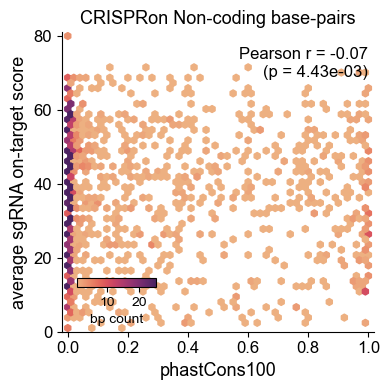

Number of base pairs covered: 1906
Pearson r: 0.082, p-value: 3.551e-04
Score and sgRNA average eff: Pearson r: -0.065, p-value: 4.432e-03
neg_lfc and sgRNA average eff: Pearson r: -0.270, p-value: 3.420e-33
Partial correlation between neg|lfc and conservation score (pcorr): 0.06674420773866274 (p-value: 0.0035628594833575183)
Partial correlation (manual via residuals): r = 0.0667, p = 0.003563


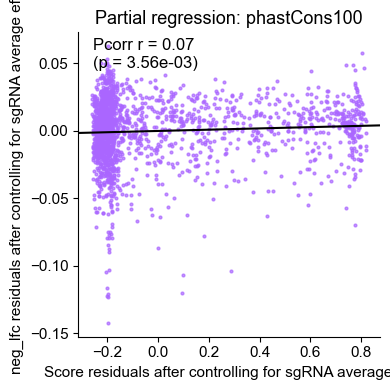

In [6]:
gene = "MYC"
myc_var = "myc2_indel"
cons_col = "indel_consequences_more"
date = "20250416"
test_name = "test-1-standard-nucleotide/test"
nc_test_name = "test-1-standard/test"
merge_method_nucleotide = "mean"
win_size = "4"
baseline = "Cas9-HMOI_D0"
treatments = ["Cas9-LMOI_D20", "Cas9-LMOI_D8", "Cas9_SpRY_L_MOI_D_20", "Cas9_SpRY_L_MOI_D_8"]
day_numbers = [20, 8, 20, 8]
# cons_subset = ["upstream_flanking", "promoter", "5_prime_UTR", "intron_1", "intron_2", "intron_splice", "3_prime_UTR", "coding", "downstream_flanking"]
cons_subset = ["upstream_flanking", "promoter", "5_prime_UTR", "intron_1", "intron_2", "intron_splice", "3_prime_UTR", "downstream_flanking"]
# cons_subset = ["promoter", "5_prime_UTR", "intron_1"]
# cons_subset = ["intron_2", "3_prime_UTR", "downstream_flanking"]
# cons_subset = ["coding"]
# cons_subset = ["promoter"]
merge_method_replicate = "mean"
conservation_method = "phastCons100"
conservation_threshold = "median"
pred_method = "CRISPRon"
sgRNA_seq_col = "target+PAM"
score_col = "Eff.(%)"
window_side_size = 2
conservation_on_target(
	gene, myc_var, cons_col,
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	cons_subset,
	merge_method_replicate,
	conservation_method, 
	conservation_threshold,
	pred_method,
	sgRNA_seq_col,
	score_col,
	window_side_size,
	per_time_unit=True,
	title="Non-coding base-pairs",
	score_smoothing=True)